<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/LOGISTIC_REGRESSION_FOR_OWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.linear_model import LogisticRegression

In [2]:
model = LogisticRegression()

   Report_ID    Incident_Type  \
0  SAFE-0001     Mask Missing   
1  SAFE-0002   Helmet Missing   
2  SAFE-0003     Mask Missing   
3  SAFE-0004  Emergency Alarm   
4  SAFE-0005   Helmet Missing   

                                         Description Risk_Level       Status  \
0  Employee entered a restricted zone without aut...        Low     Resolved   
1  Protective gloves were not used during equipme...   Moderate         Open   
2  Worker observed without proper PPE near the as...        Low  In Progress   
3  Machine produced abnormal sounds during operat...   Moderate         Open   
4  Safety helmet violation identified in construc...        Low         Open   

        Location        Reported_By  
0  Factory Floor  Christian Mercado  
1  Assembly Line       Kevin Brooks  
2   Loading Dock      Amanda Cortez  
3   Storage Area        Nicole Dyer  
4   Loading Dock     Donald Ramirez  
Predictions:
[1 0 0 1 1 0 1 0 0 2]
Accuracy : 0.36


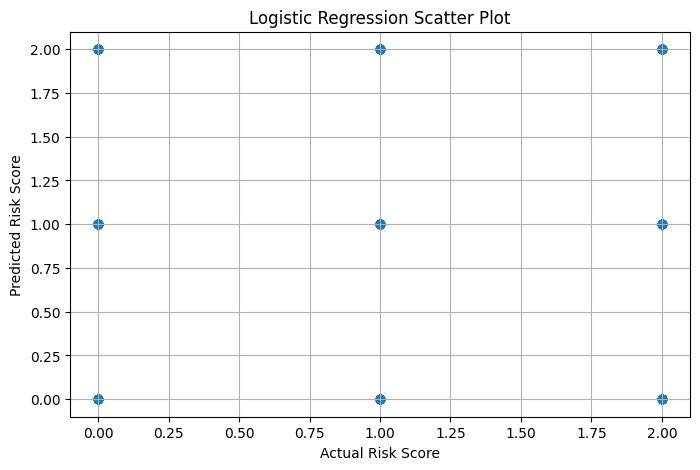

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("worker_safety_text_dataset_1000.csv")

print(df.head())

le_incident = LabelEncoder()
le_status = LabelEncoder()
le_location = LabelEncoder()
le_risk = LabelEncoder()

df["Incident_Type_encoded"] = le_incident.fit_transform(df["Incident_Type"])

df["Status_encoded"] = le_status.fit_transform(df["Status"])

df["Location_encoded"] = le_location.fit_transform(df["Location"])

df["Risk_Score"] = le_risk.fit_transform(df["Risk_Level"])

X = df[[
    "Incident_Type_encoded",
    "Status_encoded",
    "Location_encoded"
]]

y = df["Risk_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Predictions:")
print(predictions[:10])

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Risk Score")

plt.ylabel("Predicted Risk Score")

plt.title("Logistic Regression Scatter Plot")

plt.grid(True)

plt.show()

Accuracy : 0.36


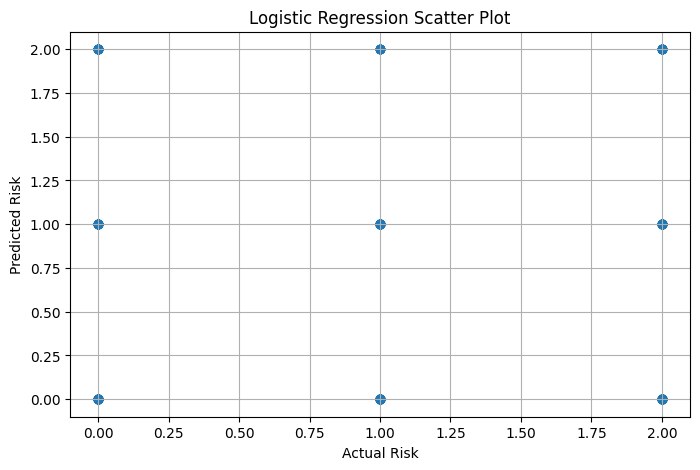

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("worker_safety_text_dataset_1000.csv")

risk_mapping = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df["Risk_Score"] = df["Risk_Level"].map(risk_mapping)

df_encoded = pd.get_dummies(
    df,
    columns=["Incident_Type", "Status", "Location"],
    dtype=int
)

X = df_encoded.drop(
    ["Risk_Level", "Risk_Score", "Description", "Report_ID", "Reported_By"],
    axis=1
)

y = df_encoded["Risk_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Risk")

plt.ylabel("Predicted Risk")

plt.title("Logistic Regression Scatter Plot")

plt.grid(True)

plt.show()